## Imports and Setup

In [2]:
import os
from pathlib import Path
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve
import warnings
warnings.filterwarnings('ignore')

# Set random seeds
np.random.seed(42)
torch.manual_seed(42)

print("All imports successful!")

All imports successful!


In [3]:
import scipy, sys
print("scipy module:", scipy)
print("scipy file:", getattr(scipy, "__file__", None))
print("scipy version attr exists?", hasattr(scipy, "__version__"))
print("sys.path[0]:", sys.path[0])


scipy module: <module 'scipy' from '/Users/tiger.c/miniforge3/envs/pds/lib/python3.10/site-packages/scipy/__init__.py'>
scipy file: /Users/tiger.c/miniforge3/envs/pds/lib/python3.10/site-packages/scipy/__init__.py
scipy version attr exists? True
sys.path[0]: /Users/tiger.c/miniforge3/envs/pds/lib/python310.zip


## Configuration

In [4]:
# Data configuration
BASELINE_DIGIT = 3  # Change this to any digit 0-9
DATA_ROOT = '../data'
FILTERED_OUT_DIR = '../score_demo/filtered'

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# Training hyperparameters
BATCH_SIZE = 128
NUM_EPOCHS = 20
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-5
LOG_EVERY = 50

# Flow architecture
INPUT_DIM = 28 * 28  # Flattened MNIST
HIDDEN_DIM = 256
NUM_BLOCKS = 4  # Number of coupling layers

# Checkpoints
FLOW_CHECKPOINT_DIR = Path('./flow_checkpoints')
FLOW_CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
FLOW_CHECKPOINT_PATH = FLOW_CHECKPOINT_DIR / f'flow_digit_{BASELINE_DIGIT}.pt'

print(f"Baseline digit: {BASELINE_DIGIT}")
print(f"Input dimension: {INPUT_DIM}")
print(f"Hidden dimension: {HIDDEN_DIM}")
print(f"Number of coupling blocks: {NUM_BLOCKS}")
print(f"Flow checkpoint: {FLOW_CHECKPOINT_PATH}")

Using device: cpu
Baseline digit: 3
Input dimension: 784
Hidden dimension: 256
Number of coupling blocks: 4
Flow checkpoint: flow_checkpoints/flow_digit_3.pt


## Load and Prepare Data

In [24]:
def load_mnist_digit(root, digit, train=True, download=True):
    """Load MNIST data filtered to a single digit."""
    ds = datasets.MNIST(root=root, train=train, download=download, transform=None)
    
    targets = ds.targets
    data = ds.data
    
    idxs = (targets == digit).nonzero(as_tuple=True)[0]
    filtered_data = data[idxs].float().div(255.0)  # [N, 28, 28]
    
    return filtered_data


# Load training data (baseline digit only)
print(f"Loading MNIST training data for digit {BASELINE_DIGIT}...")
train_data = load_mnist_digit(DATA_ROOT, BASELINE_DIGIT, train=True)
print(f"Training data shape: {train_data.shape}")
print(f"Training data - min: {train_data.min():.3f}, max: {train_data.max():.3f}, mean: {train_data.mean():.3f}")

# Load full test data
print(f"\nLoading full MNIST test data...")
test_ds = datasets.MNIST(root=DATA_ROOT, train=False, download=True, transform=None)
test_data_full = test_ds.data.float().div(255.0)
test_labels_full = test_ds.targets
print(f"Test data shape: {test_data_full.shape}")

# Create train/val split from baseline digit
n_train = int(0.8 * len(train_data))
perm = torch.randperm(len(train_data))
train_idx = perm[:n_train]
val_idx = perm[n_train:]

train_data_split = train_data[train_idx]
val_data_split = train_data[val_idx]

print(f"\nTrain/Val split:")
print(f"  Train: {train_data_split.shape[0]}")
print(f"  Val: {val_data_split.shape[0]}")

Loading MNIST training data for digit 3...
Training data shape: torch.Size([6131, 28, 28])
Training data - min: 0.000, max: 1.000, mean: 0.142

Loading full MNIST test data...
Test data shape: torch.Size([10000, 28, 28])

Train/Val split:
  Train: 4904
  Val: 1227


## Normalizing Flow Architecture (RealNVP)

RealNVP uses coupling layers where:
- Half the dimensions pass through unchanged
- Other half are transformed based on the unchanged half
- The Jacobian is triangular, so determinant is product of diagonal

In [25]:
class MLP(nn.Module):
    """Simple MLP for coupling transformation."""
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )

        # Initialize last layer to zero so coupling starts as identity (s=0,t=0)
        nn.init.zeros_(self.net[-1].weight)
        nn.init.zeros_(self.net[-1].bias)

    def forward(self, x):
        return self.net(x)


class CouplingLayer(nn.Module):
    """Coupling layer for RealNVP.

    Half dimensions are left unchanged (the "identity" part) and the other half
    are affine-transformed based on the identity part. The transform network
    takes the identity-part as input and outputs scale and translation for the
    transformed part.
    """
    def __init__(self, input_dim, hidden_dim, mask_type='even'):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim

        # Require even input_dim for a clean split
        assert input_dim % 2 == 0, "input_dim must be even"
        self.half = input_dim // 2

        # Create boolean mask buffer and index usage
        if mask_type == 'even':
            mask = (torch.arange(input_dim) % 2 == 0)
        else:  # odd
            mask = (torch.arange(input_dim) % 2 == 1)
        self.register_buffer('mask', mask)

        # Transform network: takes the identity half and outputs 2 * half (s and t)
        self.transform_net = MLP(self.half, hidden_dim, 2 * self.half)

    def forward(self, x):
        # x: [B, input_dim]
        mask = self.mask.to(x.device)

        # Select identity and transform parts by indexing columns
        x_id = x[:, mask]         # [B, half]
        x_tr = x[:, ~mask]        # [B, half]

        # Compute scale and translation from identity part
        st = self.transform_net(x_id)       # [B, 2*half]
        s, t = st.chunk(2, dim=1)           # each [B, half]

        # Stabilize scale: use tanh and small multiplier to keep exp(s) bounded
        s = 0.1 * torch.tanh(s)

        # Apply transformation to the transform-part
        y_tr = x_tr * torch.exp(s) + t

        # Reconstruct full vector
        y = x.clone()
        y[:, mask] = x_id
        y[:, ~mask] = y_tr

        # Log determinant is sum over scales in transformed part
        log_det = s.sum(dim=1)

        return y, log_det

    def inverse(self, y):
        mask = self.mask.to(y.device)

        y_id = y[:, mask]        # [B, half]
        y_tr = y[:, ~mask]       # [B, half]

        st = self.transform_net(y_id)
        s, t = st.chunk(2, dim=1)
        s = 0.1 * torch.tanh(s)

        x_tr = (y_tr - t) * torch.exp(-s)

        x = y.clone()
        x[:, mask] = y_id
        x[:, ~mask] = x_tr

        log_det = (-s).sum(dim=1)
        return x, log_det


class RealNVP(nn.Module):
    """RealNVP normalizing flow."""
    def __init__(self, input_dim, hidden_dim, num_blocks):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.num_blocks = num_blocks

        # Stack of coupling layers
        self.layers = nn.ModuleList([
            CouplingLayer(input_dim, hidden_dim, mask_type='even' if i % 2 == 0 else 'odd')
            for i in range(num_blocks)
        ])

        # Base distribution (standard normal)
        self.register_buffer('base_mean', torch.zeros(input_dim))
        self.register_buffer('base_logstd', torch.zeros(input_dim))

    def forward(self, x):
        """Transform data to latent space, return z and log_det_jac."""
        z = x.view(-1, self.input_dim)
        log_det_total = torch.zeros(z.shape[0], device=z.device)

        for layer in self.layers:
            z, log_det = layer(z)
            log_det_total += log_det

        return z, log_det_total

    def inverse(self, z):
        """Transform latent to data space."""
        x = z.view(-1, self.input_dim)
        log_det_total = torch.zeros(x.shape[0], device=x.device)

        for layer in reversed(self.layers):
            x, log_det = layer.inverse(x)
            log_det_total += log_det

        return x, log_det_total

    def log_prob(self, x):
        """Compute log probability under the learned distribution."""
        z, log_det = self.forward(x)

        # Base distribution: standard normal
        log_pz = -0.5 * (z ** 2).sum(dim=1) - 0.5 * self.input_dim * np.log(2 * np.pi)

        # Change of variables
        log_px = log_pz + log_det

        return log_px

    def sample(self, batch_size):
        """Generate samples from the learned distribution."""
        z = torch.randn(batch_size, self.input_dim, device=self.base_mean.device)
        x, _ = self.inverse(z)
        return x.clamp(0, 1)  # Ensure valid image range


# Initialize model
model = RealNVP(INPUT_DIM, HIDDEN_DIM, NUM_BLOCKS).to(DEVICE)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Model parameters: 1,471,552


## Training

In [26]:
# Prepare data loaders
train_loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(train_data_split),
    batch_size=BATCH_SIZE, shuffle=True
)
val_loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(val_data_split),
    batch_size=BATCH_SIZE, shuffle=False
)

print(f"Train loader: {len(train_loader)} batches")
print(f"Val loader: {len(val_loader)} batches")

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# Training loop
train_losses = []
val_losses = []

print(f"\n{'='*60}")
print(f"Training normalizing flow for digit {BASELINE_DIGIT}")
print(f"{'='*60}\n")

for epoch in range(1, NUM_EPOCHS + 1):
    # Training
    model.train()
    train_loss = 0.0
    n_train_batches = 0
    
    for step, (images,) in enumerate(train_loader):
        images = images.to(DEVICE)
        
        # Compute log probability
        log_prob = model.log_prob(images)
        loss = -log_prob.mean()  # Negative log likelihood
        
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        train_loss += loss.item()
        n_train_batches += 1
        
        if (step + 1) % LOG_EVERY == 0:
            print(f"Epoch {epoch} Step {step+1}/{len(train_loader)} Loss={train_loss/n_train_batches:.4f}")
    
    train_loss /= n_train_batches
    train_losses.append(train_loss)
    
    # Validation
    model.eval()
    val_loss = 0.0
    n_val_batches = 0
    
    with torch.no_grad():
        for images, in val_loader:
            images = images.to(DEVICE)
            log_prob = model.log_prob(images)
            loss = -log_prob.mean()
            val_loss += loss.item()
            n_val_batches += 1
    
    val_loss /= n_val_batches
    val_losses.append(val_loss)
    
    print(f"Epoch {epoch} Train Loss={train_loss:.4f} Val Loss={val_loss:.4f}\n")

# Save model
torch.save(model.state_dict(), FLOW_CHECKPOINT_PATH)
print(f"\n{'='*60}")
print(f"Training complete! Model saved to: {FLOW_CHECKPOINT_PATH}")
print(f"{'='*60}")

Train loader: 39 batches
Val loader: 10 batches

Training normalizing flow for digit 3

Epoch 1 Train Loss=641.9006 Val Loss=592.1847

Epoch 1 Train Loss=641.9006 Val Loss=592.1847

Epoch 2 Train Loss=588.3496 Val Loss=584.9730

Epoch 2 Train Loss=588.3496 Val Loss=584.9730

Epoch 3 Train Loss=583.9368 Val Loss=581.6210

Epoch 3 Train Loss=583.9368 Val Loss=581.6210

Epoch 4 Train Loss=580.3118 Val Loss=579.1219

Epoch 4 Train Loss=580.3118 Val Loss=579.1219

Epoch 5 Train Loss=578.1639 Val Loss=577.5063

Epoch 5 Train Loss=578.1639 Val Loss=577.5063

Epoch 6 Train Loss=576.7766 Val Loss=576.1157

Epoch 6 Train Loss=576.7766 Val Loss=576.1157

Epoch 7 Train Loss=575.5783 Val Loss=575.2624

Epoch 7 Train Loss=575.5783 Val Loss=575.2624

Epoch 8 Train Loss=574.7167 Val Loss=574.7904

Epoch 8 Train Loss=574.7167 Val Loss=574.7904

Epoch 9 Train Loss=573.9838 Val Loss=574.0353

Epoch 9 Train Loss=573.9838 Val Loss=574.0353

Epoch 10 Train Loss=573.3949 Val Loss=573.5175

Epoch 10 Train Los

## Visualize Training Progress

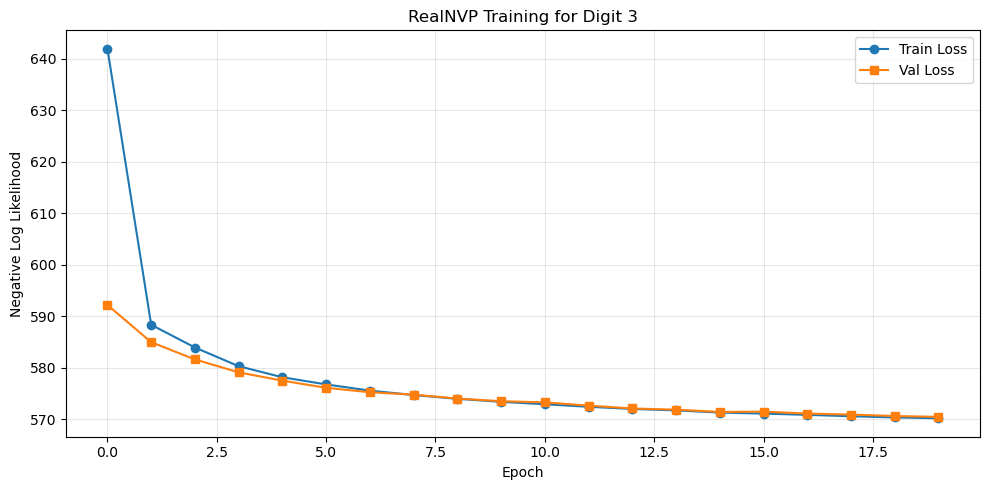

In [27]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_losses, label='Train Loss', marker='o')
ax.plot(val_losses, label='Val Loss', marker='s')
ax.set_xlabel('Epoch')
ax.set_ylabel('Negative Log Likelihood')
ax.set_title(f'RealNVP Training for Digit {BASELINE_DIGIT}')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Anomaly Detection on Test Set

In [28]:
# Compute anomaly scores (negative log likelihood)
model.eval()

test_log_probs = []
test_labels = []

with torch.no_grad():
    for i in range(0, len(test_data_full), BATCH_SIZE):
        batch_data = test_data_full[i:i+BATCH_SIZE].to(DEVICE)
        log_prob = model.log_prob(batch_data)
        test_log_probs.append(log_prob.cpu())
        test_labels.append(test_labels_full[i:i+BATCH_SIZE])

# Concatenate collected results
test_log_probs = torch.cat(test_log_probs)
test_labels = torch.cat(test_labels)

# Anomaly score = negative log likelihood (higher = more anomalous)
anomaly_scores = -test_log_probs.cpu().numpy()

# Create binary labels: baseline=0 (normal), other=1 (anomaly)
binary_labels = (test_labels.cpu().numpy() != BASELINE_DIGIT).astype(int)

# Print basic statistics (use numpy-safe ops)
print(f"Anomaly scores - min: {anomaly_scores.min():.3f}, max: {anomaly_scores.max():.3f}")
print(f"Normal (digit {BASELINE_DIGIT}) - mean: {anomaly_scores[binary_labels==0].mean():.3f}")
print(f"Anomalies (others) - mean: {anomaly_scores[binary_labels==1].mean():.3f}")

# Compute AUROC
auroc = roc_auc_score(binary_labels, anomaly_scores)
print(f"\nAUROC: {auroc:.4f}")

# Compute precision-recall and ROC
fpr, tpr, _ = roc_curve(binary_labels, anomaly_scores)
precision, recall, _ = precision_recall_curve(binary_labels, anomaly_scores)

print(f"\nAt FPR=1%:")
idx = np.argmin(np.abs(fpr - 0.01))
print(f"  TPR: {tpr[idx]:.3f}")

print(f"\nAt FPR=5%:")
idx = np.argmin(np.abs(fpr - 0.05))
print(f"  TPR: {tpr[idx]:.3f}")

Anomaly scores - min: 566.518, max: 607.228
Normal (digit 3) - mean: 570.237
Anomalies (others) - mean: 578.083

AUROC: 0.9663

At FPR=1%:
  TPR: 0.430

At FPR=5%:
  TPR: 0.726


## Visualize Results

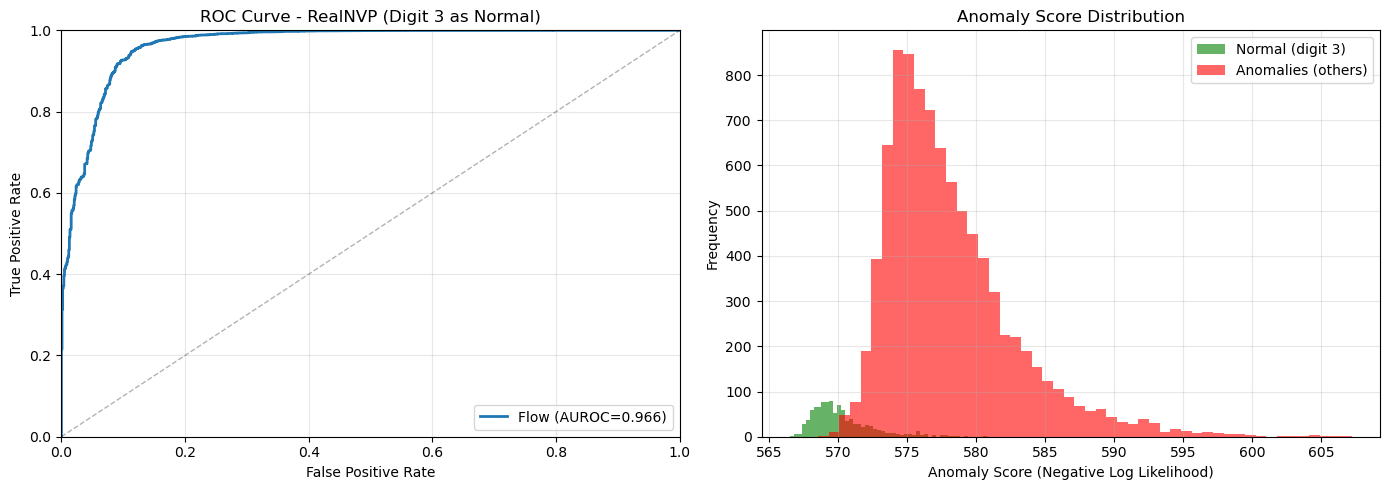

In [29]:
# Plot ROC curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC curve
axes[0].plot(fpr, tpr, lw=2, label=f'Flow (AUROC={auroc:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.3)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title(f'ROC Curve - RealNVP (Digit {BASELINE_DIGIT} as Normal)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1])

# Anomaly score distribution
axes[1].hist(anomaly_scores[binary_labels==0], bins=50, alpha=0.6, label=f'Normal (digit {BASELINE_DIGIT})', color='green')
axes[1].hist(anomaly_scores[binary_labels==1], bins=50, alpha=0.6, label='Anomalies (others)', color='red')
axes[1].set_xlabel('Anomaly Score (Negative Log Likelihood)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Anomaly Score Distribution')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Generate Samples from Learned Distribution

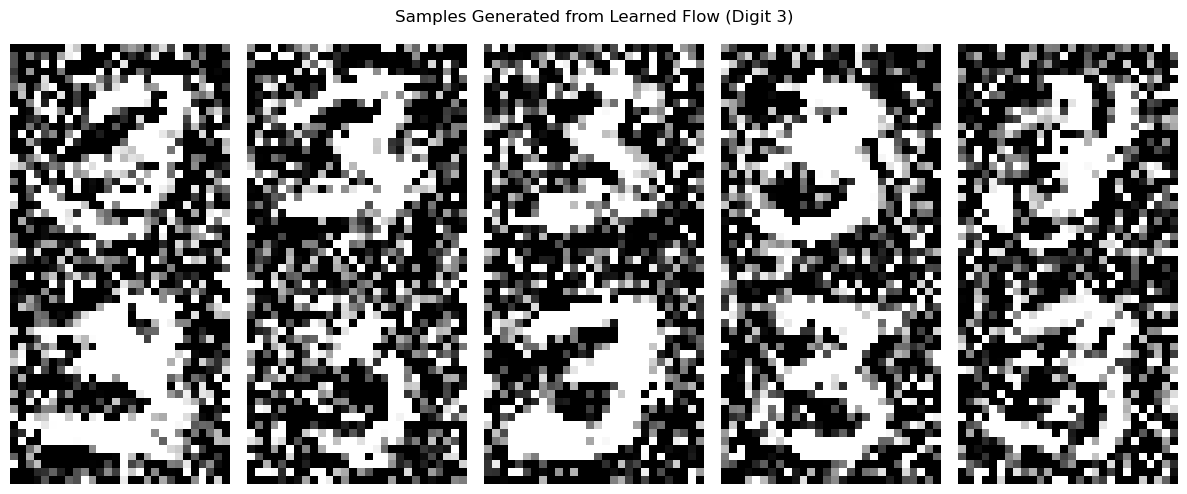

In [30]:
# Generate samples
model.eval()
with torch.no_grad():
    samples = model.sample(batch_size=10)

# Plot samples
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(samples[i].view(28, 28).cpu(), cmap='gray')
    ax.axis('off')
plt.suptitle(f'Samples Generated from Learned Flow (Digit {BASELINE_DIGIT})')
plt.tight_layout()
plt.show()

## Summary and Comparison with Score Matching

**RealNVP (Normalizing Flows) vs Score Matching:**

| Aspect | RealNVP | Score Matching |
|--------|---------|----------------|
| **Likelihood** | Exact | Approximate |
| **Training Time** | Slower | Faster |
| **Inference Speed** | Slower (need forward pass) | Fast |
| **Stability** | Requires careful architecture | More stable |
| **Sample Quality** | Good | Need reverse SDE |
| **Interpretability** | High (exact log p) | Medium (score gradients) |

**When to use each:**
- **Flows**: When exact likelihood is important, small datasets, sample generation needed
- **Score**: When speed matters, large datasets, robustness needed

In [31]:
print(f"\n{'='*60}")
print(f"Summary: Normalizing Flow Anomaly Detection")
print(f"{'='*60}")
print(f"Baseline digit: {BASELINE_DIGIT}")
print(f"AUROC: {auroc:.4f}")
print(f"Model saved to: {FLOW_CHECKPOINT_PATH}")
print(f"\nTraining used {NUM_EPOCHS} epochs with {NUM_BLOCKS} coupling layers")
print(f"Base model size: {sum(p.numel() for p in model.parameters()):,} parameters")
print(f"\nTo compare with score matching, run:")
print(f"  python score_demo/run_baseline.py --baseline {BASELINE_DIGIT}")
print(f"{'='*60}")


Summary: Normalizing Flow Anomaly Detection
Baseline digit: 3
AUROC: 0.9663
Model saved to: score_demo/checkpoints/flow_digit_3.pt

Training used 20 epochs with 4 coupling layers
Base model size: 1,471,552 parameters

To compare with score matching, run:
  python score_demo/run_baseline.py --baseline 3
